In [ ]:
import  numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('HR_comma_sep.csv')

In [ ]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
df.shape

(14999, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [ ]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
df.duplicated().sum()

np.int64(3008)

In [ ]:
print(df.duplicated())

0        False
1        False
2        False
3        False
4        False
         ...  
14994     True
14995     True
14996     True
14997     True
14998     True
Length: 14999, dtype: bool


In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['left'].value_counts()

,count
left,
0,10000
1,1991


In [ ]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

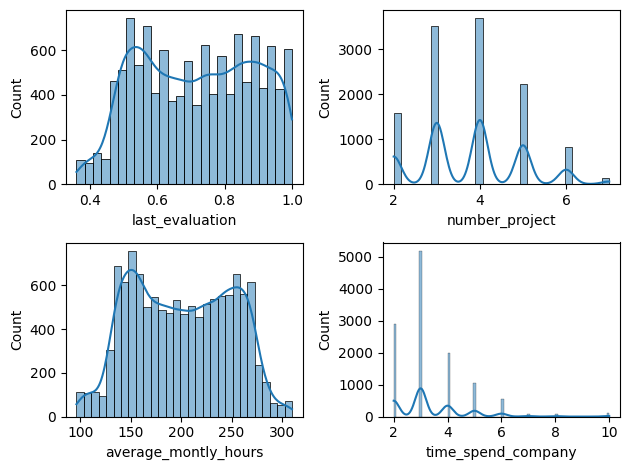

In [ ]:
def plotting(var, num):
  plt.subplot(2,2,num)
  sns.histplot(df[var], kde=True)


plotting('last_evaluation',1)
plotting('number_project',2)
plotting('average_montly_hours',3)
plotting('time_spend_company',4)

plt.tight_layout()

<Axes: xlabel='number_project', ylabel='count'>

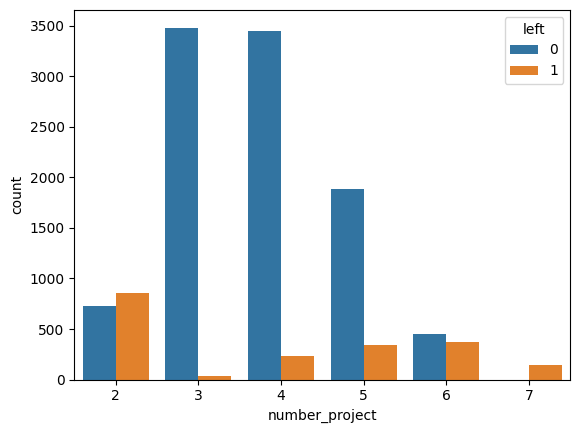

In [ ]:
sns.countplot(x=df['number_project'], hue=df['left'])

<Axes: >

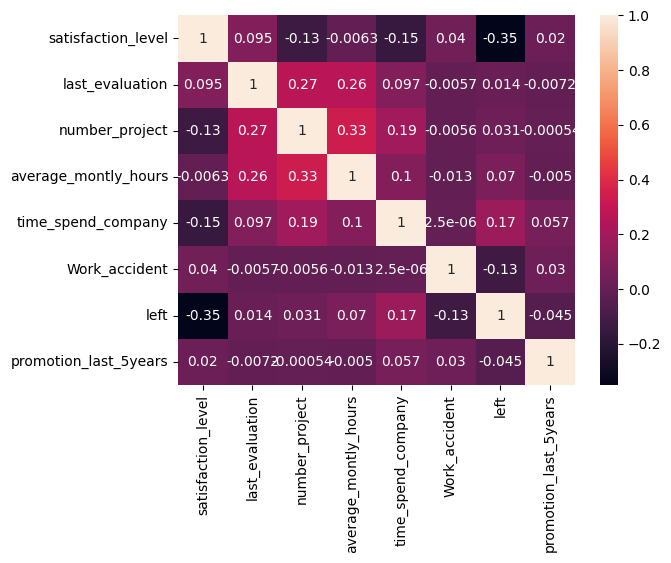

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
df['Department'].value_counts()

,count
Department,
sales,3239
technical,2244
support,1821
IT,976
RandD,694
product_mng,686
marketing,673
accounting,621
hr,601


In [ ]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
df=pd.get_dummies(df, columns=['Department','salary'], drop_first=True)


We use drop_first=True in One-Hot Encoding to avoid the Dummy Variable Trap (perfect multicollinearity). Since one encoded column can be derived from the others, dropping one category removes redundancy, reduces the number of features, and helps linear models produce stable coefficients. For a categorical variable with n categories, drop_first=True creates n−1 columns instead of n columns.

In [ ]:
df=df.astype(int)

In [ ]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0,0,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0,0,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0,0,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0,0,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0,0,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0,0,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0,0,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0,0,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0,0,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0,0,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


In [ ]:
X=df.drop('left', axis=1)
y=df['left']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[-0.08936749, -0.13311211,  1.03161902, ..., -0.4760236 ,
        -0.96073682,  1.13593723],
       [-0.08936749, -0.13311211,  1.03161902, ...,  2.10073619,
         1.04086778, -0.88033033],
       [-0.08936749, -0.13311211, -0.69064878, ..., -0.4760236 ,
        -0.96073682,  1.13593723],
       ...,
       [-0.08936749, -0.13311211,  1.03161902, ...,  2.10073619,
        -0.96073682,  1.13593723],
       [-0.08936749, -0.13311211, -1.55178267, ..., -0.4760236 ,
         1.04086778, -0.88033033],
       [-0.08936749, -0.13311211,  1.89275291, ..., -0.4760236 ,
         1.04086778, -0.88033033]])

In [ ]:
models={
    "LogisticRegression":LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

In [ ]:
result=[]

In [ ]:
for name, model in models.items():
  model.fit(X_train_scaled, y_train)
  y_pred=model.predict(X_test_scaled)
  result.append(
      {
          "Model":name,
          "Accuracy_score": round(accuracy_score(y_test,y_pred),4),
          "F1_score": round(f1_score(y_test,y_pred),4),
          "Classification Report": classification_report(y_test,y_pred),
          "Confusion Matrix": confusion_matrix(y_test,y_pred)
      }
  )

In [ ]:
for i in result:
  for k, val in i.items():
    print(f"{k} : {val}")


Model : LogisticRegression
Accuracy_score : 0.8303
F1_score : 0.0644
Classification Report :               precision    recall  f1-score   support

           0       0.84      0.99      0.91      1998
           1       0.41      0.03      0.06       401

    accuracy                           0.83      2399
   macro avg       0.62      0.51      0.49      2399
weighted avg       0.77      0.83      0.77      2399

Confusion Matrix : [[1978   20]
 [ 387   14]]
Model : KNN
Accuracy_score : 0.9379
F1_score : 0.8167
Classification Report :               precision    recall  f1-score   support

           0       0.97      0.96      0.96      1998
           1       0.81      0.83      0.82       401

    accuracy                           0.94      2399
   macro avg       0.89      0.89      0.89      2399
weighted avg       0.94      0.94      0.94      2399

Confusion Matrix : [[1918   80]
 [  69  332]]
Model : Naive Bayes
Accuracy_score : 0.2059
F1_score : 0.2952
Classification Report

In [ ]:
import  numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("spam.csv")

In [ ]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df.duplicated().sum()

np.int64(415)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Category'].value_counts()

,count
Category,
ham,4516
spam,641


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()
df['Category']=le.fit_transform(df['Category'])

In [ ]:
df['Message']=df['Message'].apply(lambda x:x.lower())

In [ ]:
import string
def remove_punc(txt):
  return txt.translate(str.maketrans('','',string.punctuation))

df['Message']=df['Message'].apply(remove_punc)

In [ ]:
def remove_emoji(txt):
  result=''.join([c for c in txt if c.isascii()])
  return result

df['Message']=df['Message'].apply(remove_emoji)


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
stop_words=stopwords.words('english')

In [ ]:
def remove(txt):
  words=word_tokenize(txt)
  result=' '.join([c for c in words if c not in stop_words])
  return result

df['Message']=df['Message'].apply(remove)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
X=df['Message']
y=df['Category']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

,Message
2598,got fujitsu ibm hp toshiba got lot model say
5418,really hows masters
99,see cup coffee animation
2321,pain couldnt come worse time
2388,also wheres piece
...,...
4750,thanx u darlinim cool thanx bday drinks 2 nite...
474,want 2 get laid tonight want real dogging loca...
3273,moon come color dreams stars make musical sms ...
4022,pick rayan macleran


In [ ]:
vectorizer=CountVectorizer()
X_train_cnt=vectorizer.fit_transform(X_train)
X_test_cnt=vectorizer.transform(X_test)
X_train_cnt.toarray()[:2]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
X_train_cnt

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 34459 stored elements and shape (4125, 8118)>

In [ ]:
X_train_dense=X_train_cnt.toarray()
X_test_dense=X_test_cnt.toarray()

In [ ]:
X_train_dense

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
models={
    "LogisticRegression":LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(kernel='rbf')
}


In [ ]:
result=[]

for name ,model in models.items():
  model.fit(X_train_dense, y_train)
  y_pred=model.predict(X_test_dense)
  result.append({
      "Model":name,
      "Accuracy_score": round(accuracy_score(y_test,y_pred),4),
      "Classification Report": classification_report(y_test,y_pred),
      "Confusion Matrix": confusion_matrix(y_test,y_pred)
  })

In [ ]:
result

[{'Model': 'LogisticRegression',
  'Accuracy_score': 0.9797,
  'Classification Report': '              precision    recall  f1-score   support\n\n           0       0.98      1.00      0.99       896\n           1       0.98      0.86      0.92       136\n\n    accuracy                           0.98      1032\n   macro avg       0.98      0.93      0.95      1032\nweighted avg       0.98      0.98      0.98      1032\n',
  'Confusion Matrix': array([[894,   2],
         [ 19, 117]])},
 {'Model': 'KNN',
  'Accuracy_score': 0.9176,
  'Classification Report': '              precision    recall  f1-score   support\n\n           0       0.91      1.00      0.95       896\n           1       0.98      0.38      0.55       136\n\n    accuracy                           0.92      1032\n   macro avg       0.95      0.69      0.75      1032\nweighted avg       0.92      0.92      0.90      1032\n',
  'Confusion Matrix': array([[895,   1],
         [ 84,  52]])},
 {'Model': 'Naive Bayes',
  'Accu

In [ ]:
X_train.head()

In [ ]:
result=[]

for name, model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  result.append({
      "Model":name,
      "Accuracy_score": round(accuracy_score(y_test,y_pred),4),
      "Classification Report": classification_report(y_test,y_pred),
      "Confusion Matrix": confusion_matrix(y_test,y_pred)
  })

In [ ]:
df['Message']

In [ ]:
df.head()